# XGBoost Phase 4: Advanced Feature Engineering & Hyperparameter Tuning

This notebook implements the fourth phase of the XGBoost benchmark. We build upon the **Weather Aware (Direct)** strategy and incorporate:
- **Rolling Load Statistics**: moving average, min, max, and std over 6h, 12h, and 24h windows before the forecast period.
- **Rolling Weather Features**: cumulative temperature, apparent temperature, and radiation over 3h, 6h, and 12h windows leading to target time.
- **Interaction Features**: temperature-humidity interaction and temperature-hour interaction.
- **Hyperparameter Tuning**: early stopping with a chronological validation split to optimize generalization.

We compare this "Advanced" model against the baseline Chronos-2 models.

In [1]:
import pandas as pd
import numpy as np
import glob
import xgboost as xgb
import holidays
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Constants
HORIZON = 24

## 1. Data Preparation

We load energy load data and merge it with the comprehensive weather dataset.

In [2]:
def load_ercot_data():
    files = sorted(glob.glob('../../data/ercot/raw/ercot_20*.xlsx'))
    dfs = []
    for f in files:
        df = pd.read_excel(f)
        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    
    def parse_ercot_datetime(s):
        s = str(s).replace(' DST', '')
        if s.endswith('24:00'):
            return pd.to_datetime(s.replace('24:00', '00:00')) + pd.Timedelta(days=1) - pd.Timedelta(hours=1)
        else:
            return pd.to_datetime(s) - pd.Timedelta(hours=1)

    df['timestamp'] = df['Hour Ending'].apply(parse_ercot_datetime)
    df = df[['timestamp', 'NCENT']].copy()
    df.rename(columns={'NCENT': 'target'}, inplace=True)
    df = df.sort_values('timestamp').set_index('timestamp')
    df = df.resample('h').mean()
    df['target'] = df['target'].interpolate()
    return df

def load_weather_data():
    files = sorted(glob.glob('../../data/ercot/raw/open-meteo-dallas-*.csv'))
    dfs = []
    for f in files:
        # Skip the metadata rows in Open-Meteo CSVs
        df_w = pd.read_csv(f, skiprows=3)
        dfs.append(df_w)
    df_w = pd.concat(dfs, ignore_index=True)
    
    df_w['timestamp'] = pd.to_datetime(df_w['time'])
    df_w = df_w.rename(columns={
        'temperature_2m (°C)': 'temp',
        'relative_humidity_2m (%)': 'humidity',
        'dew_point_2m (°C)': 'dew_point',
        'apparent_temperature (°C)': 'apparent_temp',
        'wind_speed_10m (km/h)': 'wind_speed',
        'cloud_cover (%)': 'cloud_cover',
        'precipitation (mm)': 'precip',
        'shortwave_radiation (W/m²)': 'radiation'
    })
    
    cols = ['timestamp', 'temp', 'humidity', 'dew_point', 'apparent_temp', 'wind_speed', 'cloud_cover', 'precip', 'radiation']
    df_w = df_w[cols].set_index('timestamp')
    df_w = df_w.resample('h').mean().interpolate()
    return df_w

df_load = load_ercot_data()
df_weather = load_weather_data()

# Merge datasets
df = df_load.join(df_weather, how='inner')
print(f"Merged data from {df.index.min()} to {df.index.max()}")

# Pre-compute rolling features on historical target variable (load)
for w in [6, 12, 24]:
    df[f'load_roll_mean_{w}h'] = df['target'].rolling(window=w).mean()
    df[f'load_roll_min_{w}h'] = df['target'].rolling(window=w).min()
    df[f'load_roll_max_{w}h'] = df['target'].rolling(window=w).max()
    df[f'load_roll_std_{w}h'] = df['target'].rolling(window=w).std()

# Pre-compute rolling features on weather variables (leading up to target time)
for w in [3, 6, 12]:
    df[f'temp_roll_mean_{w}h'] = df['temp'].rolling(window=w).mean()
    df[f'apparent_temp_roll_mean_{w}h'] = df['apparent_temp'].rolling(window=w).mean()
    df[f'radiation_roll_mean_{w}h'] = df['radiation'].rolling(window=w).mean()

# Pre-compute weather interaction feature
df['temp_humidity_interaction'] = df['temp'] * df['humidity']


Merged data from 2023-01-01 00:00:00 to 2026-03-31 23:00:00


## 2. Feature Engineering

In [3]:
tx_holidays = holidays.US(state='TX')

def get_calendar_features(dt_index):
    features = pd.DataFrame(index=dt_index)
    features['hour'] = dt_index.hour
    features['dayofweek'] = dt_index.dayofweek
    features['is_weekend'] = (dt_index.dayofweek >= 5).astype(int)
    features['month'] = dt_index.month
    features['is_holiday'] = pd.Series(dt_index).apply(lambda x: x in tx_holidays).values.astype(int)
    return features

## 3. Training Strategy B (Direct + Weather)

For each model $h$, we use:
- Lags from origin $T$
- Calendar features for target $T+h$
- Weather features for target $T+h$

In [4]:
train_end = '2025-07-31 23:00:00'
train_df = df[:train_end].copy()

print("Training Strategy B (Advanced Features + Early Stopping)...\n")
models_direct = {}

# Feature configuration
lag_cols = ['feat_origin', 'feat_origin_m1', 'feat_origin_m2', 
            'feat_24h_aligned', 'feat_48h_aligned', 'feat_168h_aligned']

# Rolling load features (at origin T, so no shift needed)
roll_load_cols = []
for w in [6, 12, 24]:
    roll_load_cols.extend([f'load_roll_mean_{w}h', f'load_roll_min_{w}h', 
                           f'load_roll_max_{w}h', f'load_roll_std_{w}h'])

cal_cols = ['target_hour', 'target_dayofweek', 'target_is_weekend', 'target_month', 'target_is_holiday']

# Base weather features (at target T+h)
weather_cols = ['target_temp', 'target_humidity', 'target_dew_point', 'target_apparent_temp', 
                'target_wind_speed', 'target_cloud_cover', 'target_precip', 'target_radiation']

# Rolling weather features (at target T+h)
roll_weather_cols = []
for w in [3, 6, 12]:
    roll_weather_cols.extend([f'target_temp_roll_mean_{w}h', 
                              f'target_apparent_temp_roll_mean_{w}h', 
                              f'target_radiation_roll_mean_{w}h'])

# Interaction features (at target T+h)
interaction_cols = ['target_temp_humidity_interaction', 'target_temp_hour_interaction']

feature_cols = lag_cols + roll_load_cols + cal_cols + weather_cols + roll_weather_cols + interaction_cols

for h in range(1, HORIZON + 1):
    df_h = df.copy()
    df_h['target_h'] = df_h['target'].shift(-h)
    
    # Lags (Origin T)
    df_h['feat_origin'] = df_h['target']
    df_h['feat_origin_m1'] = df_h['target'].shift(1)
    df_h['feat_origin_m2'] = df_h['target'].shift(2)
    df_h['feat_24h_aligned'] = df_h['target'].shift(24 - h)
    df_h['feat_48h_aligned'] = df_h['target'].shift(48 - h)
    df_h['feat_168h_aligned'] = df_h['target'].shift(168 - h)
    
    # Calendar (Target T+h)
    target_times = df_h.index + pd.Timedelta(hours=h)
    cal_feats = get_calendar_features(target_times)
    df_h['target_hour'] = cal_feats['hour'].values
    df_h['target_dayofweek'] = cal_feats['dayofweek'].values
    df_h['target_is_weekend'] = cal_feats['is_weekend'].values
    df_h['target_month'] = cal_feats['month'].values
    df_h['target_is_holiday'] = cal_feats['is_holiday'].values
    
    # Weather (Target T+h)
    df_h['target_temp'] = df_h['temp'].shift(-h)
    df_h['target_humidity'] = df_h['humidity'].shift(-h)
    df_h['target_dew_point'] = df_h['dew_point'].shift(-h)
    df_h['target_apparent_temp'] = df_h['apparent_temp'].shift(-h)
    df_h['target_wind_speed'] = df_h['wind_speed'].shift(-h)
    df_h['target_cloud_cover'] = df_h['cloud_cover'].shift(-h)
    df_h['target_precip'] = df_h['precip'].shift(-h)
    df_h['target_radiation'] = df_h['radiation'].shift(-h)
    
    # Rolling weather (Target T+h)
    for w in [3, 6, 12]:
        df_h[f'target_temp_roll_mean_{w}h'] = df_h[f'temp_roll_mean_{w}h'].shift(-h)
        df_h[f'target_apparent_temp_roll_mean_{w}h'] = df_h[f'apparent_temp_roll_mean_{w}h'].shift(-h)
        df_h[f'target_radiation_roll_mean_{w}h'] = df_h[f'radiation_roll_mean_{w}h'].shift(-h)
        
    # Interactions (Target T+h)
    df_h['target_temp_humidity_interaction'] = df_h['temp_humidity_interaction'].shift(-h)
    df_h['target_temp_hour_interaction'] = df_h['target_temp'] * df_h['target_hour']
    
    df_h = df_h.dropna()
    train_h = df_h[:train_end]
    
    # Validation split for early stopping (chronological split)
    val_size = int(len(train_h) * 0.15)
    train_split = train_h.iloc[:-val_size]
    val_split = train_h.iloc[-val_size:]
    
    m = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=20,
        random_state=42
    )
    m.fit(
        train_split[feature_cols].astype(float), 
        train_split['target_h'],
        eval_set=[(val_split[feature_cols].astype(float), val_split['target_h'])],
        verbose=False
    )
    models_direct[h] = m
print("Done training models!")

Training Strategy B (Advanced Features + Early Stopping)...



Done training models!


## 4. Evaluation

In [5]:
def calculate_metrics(y_true, y_pred, y_train):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))
    mae_naive = mean_absolute_error(y_train[168:], y_train[:-168])
    mase = mae / mae_naive
    return {'MAE': mae, 'RMSE': rmse, 'sMAPE': smape, 'MASE': mase}

def evaluate_weather_direct(test_df):
    all_preds = []
    all_actuals = []
    origins = test_df[test_df.index.hour == 0].index
    for origin in origins:
        if origin + pd.Timedelta(hours=24) > test_df.index[-1]:
            continue
        actual = test_df.loc[origin + pd.Timedelta(hours=1) : origin + pd.Timedelta(hours=24), 'target'].values
        
        preds = []
        for h in range(1, 25):
            target_time = origin + pd.Timedelta(hours=h)
            cal = get_calendar_features(pd.DatetimeIndex([target_time]))
            w = df.loc[target_time]
            
            row_dict = {
                'feat_origin': df.loc[origin, 'target'],
                'feat_origin_m1': df.loc[origin - pd.Timedelta(hours=1), 'target'],
                'feat_origin_m2': df.loc[origin - pd.Timedelta(hours=2), 'target'],
                'feat_24h_aligned': df.loc[origin - pd.Timedelta(hours=24-h), 'target'],
                'feat_48h_aligned': df.loc[origin - pd.Timedelta(hours=48-h), 'target'],
                'feat_168h_aligned': df.loc[origin - pd.Timedelta(hours=168-h), 'target'],
                'target_hour': cal['hour'].values[0],
                'target_dayofweek': cal['dayofweek'].values[0],
                'target_is_weekend': cal['is_weekend'].values[0],
                'target_month': cal['month'].values[0],
                'target_is_holiday': cal['is_holiday'].values[0],
                'target_temp': w['temp'],
                'target_humidity': w['humidity'],
                'target_dew_point': w['dew_point'],
                'target_apparent_temp': w['apparent_temp'],
                'target_wind_speed': w['wind_speed'],
                'target_cloud_cover': w['cloud_cover'],
                'target_precip': w['precip'],
                'target_radiation': w['radiation'],
                'target_temp_hour_interaction': w['temp'] * cal['hour'].values[0]
            }
            
            # Add rolling load stats from origin
            for col in roll_load_cols:
                row_dict[col] = df.loc[origin, col]
                
            # Add rolling weather and interaction stats from target_time
            for w_win in [3, 6, 12]:
                row_dict[f'target_temp_roll_mean_{w_win}h'] = w[f'temp_roll_mean_{w_win}h']
                row_dict[f'target_apparent_temp_roll_mean_{w_win}h'] = w[f'apparent_temp_roll_mean_{w_win}h']
                row_dict[f'target_radiation_roll_mean_{w_win}h'] = w[f'radiation_roll_mean_{w_win}h']
                
            row_dict['target_temp_humidity_interaction'] = w['temp_humidity_interaction']
            
            feats = pd.DataFrame([row_dict])
            preds.append(models_direct[h].predict(feats[feature_cols].astype(float))[0])
        all_preds.append(preds)
        all_actuals.append(actual)
    return np.array(all_actuals), np.array(all_preds)

aug_df = df['2025-08-01 00:00:00':'2025-08-31 23:00:00']
mar_df = df['2026-03-01 00:00:00':'2026-03-31 23:00:00']

for window_name, test_df in [("August 2025", aug_df), ("March 2026", mar_df)]:
    act, p_dir = evaluate_weather_direct(test_df)
    print(f"\nResults for {window_name} (XGBoost Advanced):")
    print(calculate_metrics(act.flatten(), p_dir.flatten(), train_df['target']))


Results for August 2025 (XGBoost Advanced):
{'MAE': 609.2617671396702, 'RMSE': np.float64(811.170110847647), 'sMAPE': np.float64(3.1603327403956207), 'MASE': 0.31770423786784624}



Results for March 2026 (XGBoost Advanced):
{'MAE': 557.3700284769965, 'RMSE': np.float64(690.4419266632759), 'sMAPE': np.float64(4.189632091891162), 'MASE': 0.29064489133957017}


## 5. Visualization

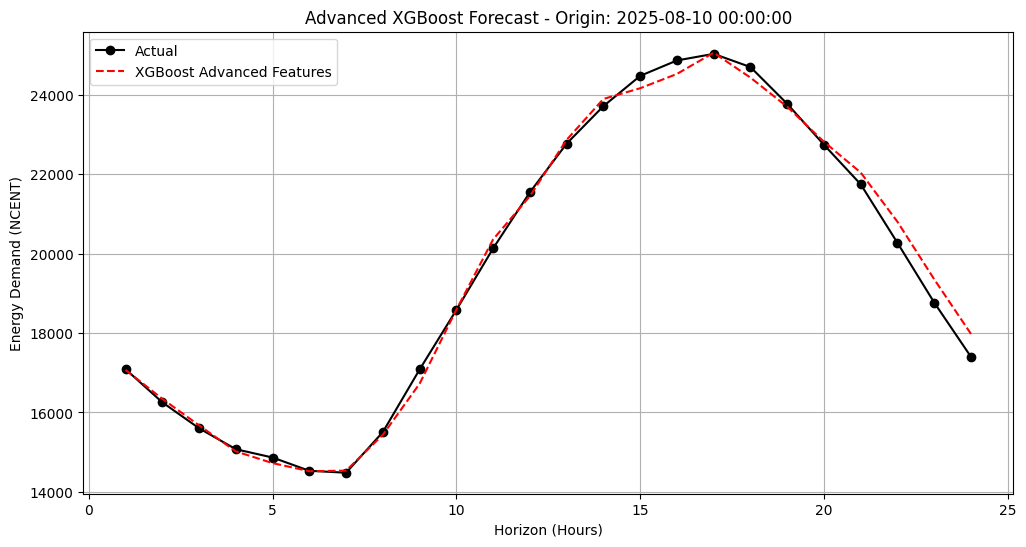

In [6]:
sample_origin = pd.to_datetime('2025-08-10 00:00:00')
act_sample = aug_df.loc[sample_origin + pd.Timedelta(hours=1) : sample_origin + pd.Timedelta(hours=24), 'target'].values

wea_preds = []
for h in range(1, 25):
    target_time = sample_origin + pd.Timedelta(hours=h)
    cal = get_calendar_features(pd.DatetimeIndex([target_time]))
    w = df.loc[target_time]
    
    row_dict = {
        'feat_origin': df.loc[sample_origin, 'target'],
        'feat_origin_m1': df.loc[sample_origin - pd.Timedelta(hours=1), 'target'],
        'feat_origin_m2': df.loc[sample_origin - pd.Timedelta(hours=2), 'target'],
        'feat_24h_aligned': df.loc[sample_origin - pd.Timedelta(hours=24-h), 'target'],
        'feat_48h_aligned': df.loc[sample_origin - pd.Timedelta(hours=48-h), 'target'],
        'feat_168h_aligned': df.loc[sample_origin - pd.Timedelta(hours=168-h), 'target'],
        'target_hour': cal['hour'].values[0],
        'target_dayofweek': cal['dayofweek'].values[0],
        'target_is_weekend': cal['is_weekend'].values[0],
        'target_month': cal['month'].values[0],
        'target_is_holiday': cal['is_holiday'].values[0],
        'target_temp': w['temp'],
        'target_humidity': w['humidity'],
        'target_dew_point': w['dew_point'],
        'target_apparent_temp': w['apparent_temp'],
        'target_wind_speed': w['wind_speed'],
        'target_cloud_cover': w['cloud_cover'],
        'target_precip': w['precip'],
        'target_radiation': w['radiation'],
        'target_temp_hour_interaction': w['temp'] * cal['hour'].values[0]
    }
    
    # Add rolling load stats from origin
    for col in roll_load_cols:
        row_dict[col] = df.loc[sample_origin, col]
        
    # Add rolling weather and interaction stats from target_time
    for w_win in [3, 6, 12]:
        row_dict[f'target_temp_roll_mean_{w_win}h'] = w[f'temp_roll_mean_{w_win}h']
        row_dict[f'target_apparent_temp_roll_mean_{w_win}h'] = w[f'apparent_temp_roll_mean_{w_win}h']
        row_dict[f'target_radiation_roll_mean_{w_win}h'] = w[f'radiation_roll_mean_{w_win}h']
        
    row_dict['target_temp_humidity_interaction'] = w['temp_humidity_interaction']
    
    feats = pd.DataFrame([row_dict])
    wea_preds.append(models_direct[h].predict(feats[feature_cols].astype(float))[0])

plt.figure(figsize=(12, 6))
plt.plot(range(1, 25), act_sample, label='Actual', marker='o', color='black')
plt.plot(range(1, 25), wea_preds, label='XGBoost Advanced Features', linestyle='--', color='red')
plt.title(f"Advanced XGBoost Forecast - Origin: {sample_origin}")
plt.xlabel("Horizon (Hours)")
plt.ylabel("Energy Demand (NCENT)")
plt.legend()
plt.grid(True)
plt.show()